In [23]:
import pandas as pd

In [24]:
DATASET = './datasets/paysim/paysim100.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft
0,0,TRANSFER,10.00,C4335240963,65.90,55.90,C9522727029,56.25,66.25,0,0,0
1,0,TRANSFER,50.00,C7602185929,12.91,-37.09,C9522727029,66.25,116.25,0,0,0
2,0,TRANSFER,10.00,C1262480323,31.26,21.26,C9522727029,116.25,126.25,0,0,0
3,1,CASH_IN,134217.76,C6506305345,77.65,134295.41,M3402039221,0.00,0.00,0,0,0
4,1,CASH_IN,68084.39,C3913343561,13.28,68097.68,M6350945077,0.00,0.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
16734,361,PAYMENT,11994.79,C4231416570,4720028.75,4708033.95,M9860527601,615259.50,627254.29,0,0,0
16735,361,CASH_IN,231685.40,C0158123010,3739744.30,3971429.70,M4540930007,619940.56,619940.56,0,0,0
16736,361,CASH_IN,217636.85,C4461856486,2547373.51,2765010.36,M1060572299,709770.57,709770.57,0,0,0
16737,361,CASH_OUT,192509.05,C0144874431,4234858.13,4042349.07,M7350285219,645589.51,645589.51,0,0,0


In [25]:
balances = {}

for _, row in df.iterrows():
    # Track origin account
    if row['nameOrig'] not in balances:
        balances[row['nameOrig']] = {}
    balances[row['nameOrig']][row['step']] = row['newBalanceOrig']

    # Track destination account
    if row['nameDest'] not in balances:
        balances[row['nameDest']] = {}
    balances[row['nameDest']][row['step']] = row['newBalanceDest']


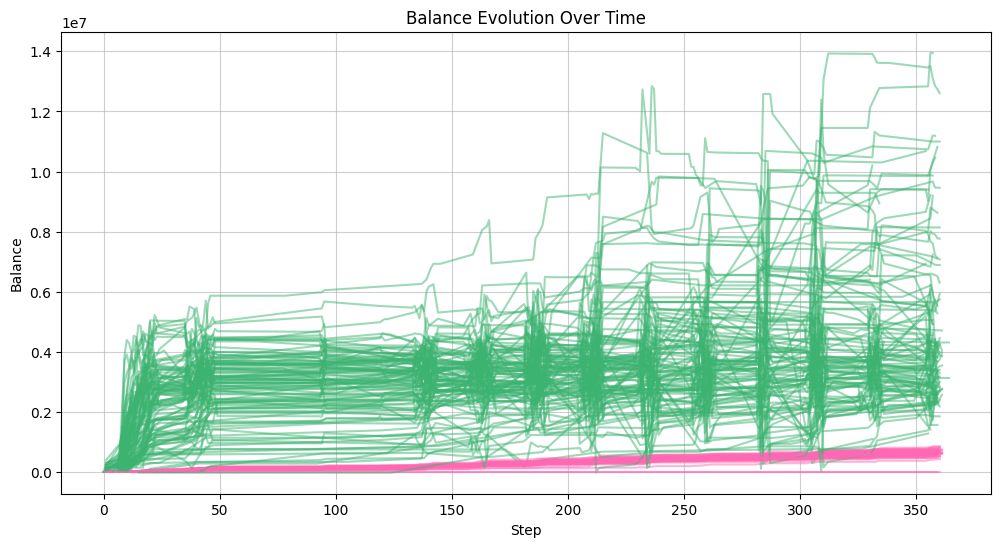

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for account, balance_data in balances.items():
    steps = sorted(balance_data.keys())  # Sort steps for chronological order
    balances_values = [balance_data[step] for step in steps]

    color = 'mediumseagreen' if account.startswith('C') else 'hotpink'

    plt.plot(steps, balances_values, label=account, color=color, alpha=0.5)

plt.title("Balance Evolution Over Time")
plt.xlabel("Step")
plt.ylabel("Balance")
plt.grid(True, linestyle='solid', alpha=0.6)

plt.show()